<a href="https://colab.research.google.com/github/dohaalnabahin/Data_science_and_machine_learning_Journey/blob/main/Feature_Engineering_Holidays.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install holidays

In [4]:
import holidays
import datetime as dt
from holidays import country_holidays
import pandas as pd


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [35]:
import pandas as pd

df = pd.read_csv(
    "/content/baltimore_crime_counts_2023.csv",
    parse_dates=["CrimeDateTime"]
)

df.head()

,CrimeDateTime,LARCENY,RAPE,AGG. ASSAULT,LARCENY FROM AUTO,BURGLARY,COMMON ASSAULT,AUTO THEFT,ROBBERY,ROBBERY - COMMERCIAL,ARSON,ROBBERY - CARJACKING,HOMICIDE,SHOOTING
0,2011-01-01,39,5,28,27,21,41,15,5,2,1.0,NaN,NaN,NaN
1,2011-01-02,20,2,6,20,19,14,5,10,1,0.0,NaN,NaN,NaN
2,2011-01-03,19,1,13,16,21,15,7,9,1,0.0,NaN,NaN,NaN
3,2011-01-04,29,1,11,12,12,29,10,4,0,0.0,NaN,NaN,NaN
4,2011-01-05,30,0,9,14,28,26,10,6,2,0.0,NaN,NaN,NaN


In [36]:
df["CrimeDateTime"] = pd.to_datetime(df["CrimeDateTime"])

df = df.loc[
    (df["CrimeDateTime"] >= "2011-01-01") &
    (df["CrimeDateTime"] <= "2022-12-31")
].copy()

all_days = pd.date_range(df["CrimeDateTime"].min(), df["CrimeDateTime"].max())

all_days

DatetimeIndex(['2011-01-01', '2011-01-02', '2011-01-03', '2011-01-04',
               '2011-01-05', '2011-01-06', '2011-01-07', '2011-01-08',
               '2011-01-09', '2011-01-10',
               ...
               '2022-12-22', '2022-12-23', '2022-12-24', '2022-12-25',
               '2022-12-26', '2022-12-27', '2022-12-28', '2022-12-29',
               '2022-12-30', '2022-12-31'],
              dtype='datetime64[ns]', length=4383, freq='D')

#Getting General US Holidays

In [37]:
## Create an instance of the US country holidays.
us_holidays = country_holidays('US')
us_holidays

holidays.country_holidays('US')

In [38]:
## Testing first date
print(all_days[0])
us_holidays.get(all_days[0])

2011-01-01 00:00:00


"New Year's Day"

In [39]:
## Getting us holidays for all dates
holiday_list = [us_holidays.get(day) for day in all_days]
holiday_list[:5]

["New Year's Day", None, None, None, None]

#Getting Sub-Region Holidays

In [40]:
# For a specific subdivisions (e.g. state or province):
md_holidays = country_holidays('US', subdiv='MD')
md_holidays

holidays.country_holidays('US', subdiv='MD')

In [42]:
## Saving both holiday types as columns
df["US Holiday"] = [us_holidays.get(day) for day in df['CrimeDateTime']]
df['MD Holiday'] = [md_holidays.get(day) for day in df['CrimeDateTime']]
df.head()

,CrimeDateTime,LARCENY,RAPE,AGG. ASSAULT,LARCENY FROM AUTO,BURGLARY,COMMON ASSAULT,AUTO THEFT,ROBBERY,ROBBERY - COMMERCIAL,ARSON,ROBBERY - CARJACKING,HOMICIDE,SHOOTING,US Holiday,MD Holiday
0,2011-01-01,39,5,28,27,21,41,15,5,2,1.0,NaN,NaN,NaN,New Year's Day,New Year's Day
1,2011-01-02,20,2,6,20,19,14,5,10,1,0.0,NaN,NaN,NaN,None,None
2,2011-01-03,19,1,13,16,21,15,7,9,1,0.0,NaN,NaN,NaN,None,None
3,2011-01-04,29,1,11,12,12,29,10,4,0,0.0,NaN,NaN,NaN,None,None
4,2011-01-05,30,0,9,14,28,26,10,6,2,0.0,NaN,NaN,NaN,None,None


In [50]:
crime_columns = ['LARCENY', 'RAPE', 'AGG. ASSAULT', 'LARCENY FROM AUTO', 'BURGLARY', 'COMMON ASSAULT', 'AUTO THEFT', 'ROBBERY', 'ROBBERY - COMMERCIAL', 'ARSON', 'ROBBERY - CARJACKING', 'HOMICIDE', 'SHOOTING']
df['Total_Incidents'] = df[crime_columns].sum(axis=1)

df.head()

,CrimeDateTime,LARCENY,RAPE,AGG. ASSAULT,LARCENY FROM AUTO,BURGLARY,COMMON ASSAULT,AUTO THEFT,ROBBERY,ROBBERY - COMMERCIAL,ARSON,ROBBERY - CARJACKING,HOMICIDE,SHOOTING,US Holiday,MD Holiday,Total_Incidents
0,2011-01-01,39,5,28,27,21,41,15,5,2,1.0,NaN,NaN,NaN,New Year's Day,New Year's Day,184.0
1,2011-01-02,20,2,6,20,19,14,5,10,1,0.0,NaN,NaN,NaN,None,None,97.0
2,2011-01-03,19,1,13,16,21,15,7,9,1,0.0,NaN,NaN,NaN,None,None,102.0
3,2011-01-04,29,1,11,12,12,29,10,4,0,0.0,NaN,NaN,NaN,None,None,108.0
4,2011-01-05,30,0,9,14,28,26,10,6,2,0.0,NaN,NaN,NaN,None,None,125.0


In [43]:
## US Holidays
df['US Holiday'].value_counts()

,count
US Holiday,
New Year's Day,12
Martin Luther King Jr. Day,12
Washington's Birthday,12
Memorial Day,12
Independence Day,12
Labor Day,12
Columbus Day,12
Veterans Day,12
Thanksgiving Day,12


In [44]:
## MD Holidays
df['MD Holiday'].value_counts()

,count
MD Holiday,
New Year's Day,12
Presidents' Day,12
Memorial Day,12
Veterans Day,12
Independence Day,12
Labor Day,12
Columbus Day,12
American Indian Heritage Day,12
Thanksgiving Day,12


In [48]:
import seaborn as sns
import numpy as np


/tmp/ipykernel_9437/3632297640.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=45, ha='right');


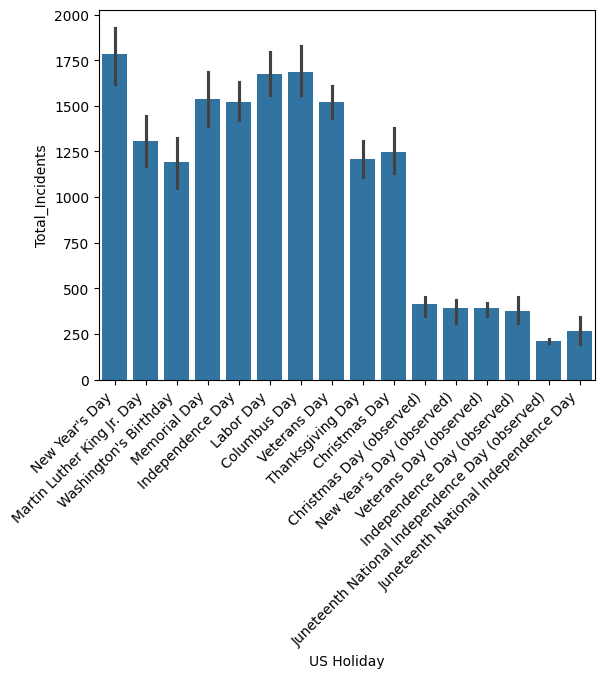

In [51]:
ax = sns.barplot(data=df, x='US Holiday',y='Total_Incidents',estimator=np.sum)
ax.set_xticklabels(ax.get_xticklabels(),rotation=45, ha='right');

In [52]:
## Saving a binary is holiday feature
df['Is_Holiday'] = df['US Holiday'].notna()
df['Is_Holiday'].value_counts()

,count
Is_Holiday,
False,4246
True,137
